In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

import geopandas as gpd
import regionmask
import cartopy.crs as ccrs
import matplotlib.patheffects as pe

# Functions to make the script more readable. 
import Kyrafunctions as ky

import sys
sys.path.append('../code')
import SeaLevelContrib as slc


In [2]:
#Mass changes Gravis gridded: 
data_path = '../data/GravIs/'
ant = xr.open_dataset(data_path + "GRAVIS-3_COSTG_0100_AIS_GRID_TUD_0003.nc")
display(ant) 

# Mass changes Gravis region: 
ant_region = pd.read_csv(data_path + 'AIS_COSTG_0100_0003.csv')
display(ant_region)

# Open the geojson file with the region shapes of antarctica. 
ant_region_shapes = gpd.read_file(data_path + "antarctica.geojson")
gre_region_shapes = gpd.read_file(data_path + "greenland.geojson")

display(ant_region_shapes)
print(type(ant_region_shapes))

<xarray.Dataset> Size: 22MB
Dimensions:   (time: 240, y: 97, x: 117)
Coordinates:
  * x         (x) float64 936B -2.9e+06 -2.85e+06 -2.8e+06 ... 2.85e+06 2.9e+06
  * y         (y) float64 776B -2.4e+06 -2.35e+06 -2.3e+06 ... 2.35e+06 2.4e+06
  * time      (time) datetime64[ns] 2kB 2002-04-18 ... 2024-12-16T12:00:00
Data variables:
    time_dec  (time) float64 2kB ...
    lon       (y, x) float64 91kB ...
    lat       (y, x) float64 91kB ...
    dm        (time, y, x) float64 22MB ...
    area      (y, x) float64 91kB ...
    crs       |S1 1B ...
Attributes: (12/16)
    title:                Gridded AIS Mass Changes
    institution:          TU Dresden, Chair of Geodetic Earth System Research
    authors:              Andreas Groh, Martin Horwath, Thorben Döhne
    project:              GravIS GRACE/GRACE-FO Level-3 Products
    source:               Monthly COST-G RL01 GRACE/GRACE-FO Level-2B product...
    summary:              GRACE/GRACE-FO derived time series of gridded Antar...
    ...                   ...
    product_version:      0003
    doi:                  10.5880/COST-G.GRAVIS_01_L3_ICE
    netCDF_version:       netCDF-4_classic
    conventions:          CF-1.6
    date_created:         2025-04-07
    contact:              thorben.doehne@tu-dresden.de

,time [yyyy_doy],time [yyyy-mm-dd],global [Gt],uncertainty_global [Gt],301 [Gt],uncertainty_301 [Gt],302 [Gt],uncertainty_302 [Gt],303 [Gt],uncertainty_303 [Gt],...,321 [Gt],uncertainty_321 [Gt],322 [Gt],uncertainty_322 [Gt],323 [Gt],uncertainty_323 [Gt],324 [Gt],uncertainty_324 [Gt],325 [Gt],uncertainty_325 [Gt]
0,2002_108,2002-04-18,783.5572,39.7671,-185.5918,8.0361,21.7319,3.9759,-92.8456,8.0322,...,501.1376,9.5865,320.3101,10.6224,165.0327,10.5266,32.8292,8.2482,221.5869,10.2016
1,2002_129,2002-05-09,1024.7474,39.6618,-143.0508,8.0148,13.9175,3.9653,-61.2555,8.0109,...,514.7867,9.5612,274.9547,10.5943,216.3137,10.4987,44.8329,8.2264,249.7929,10.1746
2,2002_228,2002-08-16,928.5683,32.0782,-150.1679,6.4823,30.4260,3.2071,-84.9035,6.4792,...,482.8047,7.7330,285.8051,8.5686,184.8797,8.4913,29.9275,6.6535,206.6849,8.2291
3,2002_258,2002-09-15,1045.5888,40.1956,-170.5825,8.1227,35.6658,4.0187,-74.4790,8.1187,...,491.4216,9.6898,312.8551,10.7369,184.7593,10.6400,36.7605,8.3371,205.6400,10.3115
4,2002_289,2002-10-16,1208.1679,29.4714,-153.6786,5.9555,36.2826,2.9465,-40.3099,5.9527,...,504.1893,7.1046,282.7808,7.8723,211.0457,7.8013,54.4778,6.1128,220.4352,7.5604
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,2024_229,2024-08-16,-1415.3003,28.1023,332.1009,5.6789,-42.0983,2.8096,131.5216,5.6761,...,-985.8253,6.7746,-693.2070,7.5066,-381.3176,7.4389,-53.2465,5.8288,-160.9599,7.2092
236,2024_260,2024-09-16,-1489.8178,32.8477,334.5339,6.6378,-29.3350,3.2841,128.5114,6.6346,...,-988.4958,7.9185,-692.6685,8.7741,-392.8872,8.6950,-38.3244,6.8130,-144.9099,8.4265
237,2024_290,2024-10-16,-1558.3124,31.0070,360.7525,6.2659,-38.5561,3.1000,133.6025,6.2628,...,-989.7893,7.4748,-718.7441,8.2825,-374.7592,8.2077,-56.5755,6.4313,-155.6476,7.9543
238,2024_320,2024-11-15,-1696.3919,27.0272,376.6739,5.4616,-34.8480,2.7022,127.4483,5.4590,...,-976.9130,6.5154,-744.2125,7.2194,-383.0067,7.1543,-54.9900,5.6058,-160.6984,6.9334


Skipping field extent: unsupported OGR type: 3
Skipping field extent: unsupported OGR type: 3


,set,calc,display,name,changed,hash,geometry
0,AIS,True,True,301,1.747299e+09,sha256:1ef6d18e1dd65a35acd08a83cfce559fea8767f...,"POLYGON ((-98.82038 -84.60183, -98.82038 -84.6..."
1,AIS,True,True,302,1.747299e+09,sha256:d2aef10e87edc2744faa5a2fb6c4b495805bea5...,"POLYGON ((161.56505 -88.54485, 165.96375 -88.4..."
2,AIS,True,True,303,1.747299e+09,sha256:ca9c99e8093d29212364863ccac56a493857594...,"POLYGON ((23.02549 -86.00141, 23.02549 -86.001..."
3,AIS,True,True,304,1.747299e+09,sha256:f22f1c3360da8b8d7d3a8290d610d7802607b9d...,"MULTIPOLYGON (((-17.37893 -77.41529, -17.77641..."
4,AIS,True,True,305,1.747299e+09,sha256:8545724ddab1a83eec491328f7eacbba253c487...,"MULTIPOLYGON (((-2.94252 -70.46207, -3.20949 -..."
5,AIS,True,True,306,1.747299e+09,sha256:a3ceb420c629b9f5c6556aebcfbf3957b8ce25e...,"POLYGON ((38.34079 -77.14424, 38.34079 -77.144..."
6,AIS,True,True,307,1.747299e+09,sha256:05c5e2f7322d6360b614bc82f280f4b22d5dbcc...,"MULTIPOLYGON (((39.17366 -77.22914, 39.17366 -..."
7,AIS,True,True,308,1.747299e+09,sha256:6e27bef76c82f79cb305c8a75781a7929f56e1b...,"MULTIPOLYGON (((48.49706 -66.83562, 48.32924 -..."
8,AIS,True,True,309,1.747299e+09,sha256:7fe450265892357519fb6c4e69d7169c293ea97...,"POLYGON ((71.95218 -81.40039, 71.37214 -81.371..."
9,AIS,True,True,310,1.747299e+09,sha256:073cfd017f629a14bff0c355cf4f750dbf62f68...,"MULTIPOLYGON (((93.59877 -75.41338, 93.59877 -..."


<class 'geopandas.geodataframe.GeoDataFrame'>


In [3]:
#Calculations: 

antdif = ant['dm'].isel(time=-1)-ant['dm'].isel(time=0)



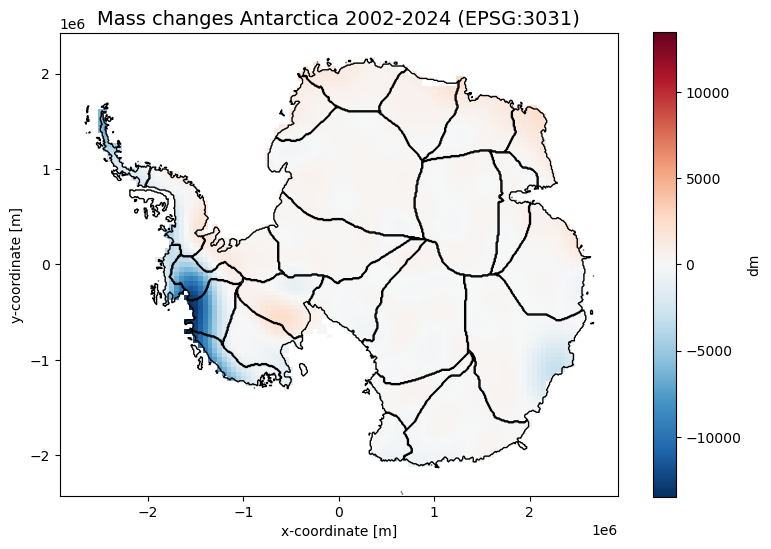

In [4]:
# Reproject to Antarctic polar stereographic
ant_proj = ant_region_shapes.to_crs("EPSG:3031")

# Create figure + axis
fig, ax = plt.subplots(figsize=(9, 9))

antdif.plot(ax=ax, cbar_kwargs={'shrink': 0.67})

# 2. Overlay Antarctica outline on the SAME axis
ant_proj.plot(
    edgecolor='black',
    facecolor='none',     # keep dm visible so no color 
    ax=ax
)

plt.title("Mass changes Antarctica 2002-2024 (EPSG:3031)", fontsize=14)
plt.show()


<GeoAxes: >

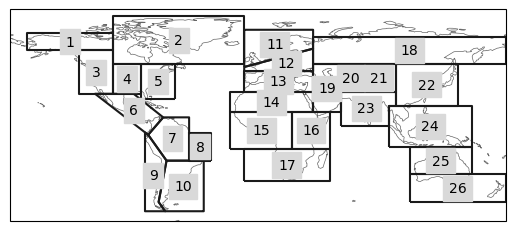

In [5]:
srex = regionmask.defined_regions.srex
srex
srex.plot()

In [6]:
#ant_region_shapes mask geopend geojson: # Open the geojson file with the region shapes of antarctica. 
#ant_region_shapes = gpd.read_file(data_path + "antarctica.geojson")



lon = np.arange(-180, 180)
lat = np.arange(-90, 90)

mask = regionmask.mask_geopandas(ant_region_shapes, lon, lat)

f, ax = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()))
mask.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
)

ax.coastlines(color="0.1");



ValueError: Found overlapping regions for ``overlap=None``. Please create a 3D mask. You may want to explicitly set ``overlap`` to ``True`` or ``False``.